## Feature Importance testing for bike sharing dataset

This notebook contains the feature importance testing conducted in support of data science tasks performed for this project.  
In particular, since we have 44 features of multiple types (i.e number, string, date and datetime) it is highly unlikely that all of them will contribute equally to the prediction process.   
In fact, some of them would be irrelevant and others will offer very little in terms, which would most likely result in an incorrectly skewed distribution, which will yield incorrect predictions.

To avoid this, I check and compare the importance of the features based on their data type and select only the most relevant features of each data type (if they exist).  
I use the XGBoost model to conduct the feature importance stage.

In [1]:
library("tidymodels")
library("tidyverse")
library("stringr")
library("xgboost")

── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.5     ✔ recipes      1.0.8
✔ dials        1.2.0     ✔ rsample      1.2.0
✔ dplyr        1.1.3     ✔ tibble       3.2.1
✔ ggplot2      3.4.4     ✔ tidyr        1.3.0
✔ infer        1.0.5     ✔ tune         1.1.2
✔ modeldata    1.2.0     ✔ workflows    1.1.3
✔ parsnip      1.1.1     ✔ workflowsets 1.0.1
✔ purrr        1.0.2     ✔ yardstick    1.2.0

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()
• Use suppressPackageStartupMessages() to eliminate package startup messages

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.4
✔ lubridate 1.9.3     ✔ stringr   1.5.0
── Conflicts ────────────────────────────────────────── tidyverse_co

The `seoul_bike_sharing_converted_normalized.csv` will be our main dataset which has following variables:

The response variable:
- `RENTED BIKE COUNT`- Count of bikes rented at each hour

Weather predictor variables:
- `TEMPERATURE` - Temperature in Celsius
- `HUMIDITY` - Unit is `%`
- `WIND_SPEED` - Unit is `m/s`
- `VISIBILITY` - Multiplied by 10m
- `DEW_POINT_TEMPERATURE` - The temperature to which the air would have to cool down in order to reach saturation, unit is Celsius
- `SOLAR_RADIATION` - MJ/m2
- `RAINFALL` - mm
- `SNOWFALL` - cm

Date/time predictor variables:
- `DATE` - Year-month-day
- `HOUR`- Hour of he day
- `FUNCTIONAL DAY` - NoFunc(Non Functional Hours), Fun(Functional hours)
- `HOLIDAY` - Holiday/No holiday
- `SEASONS` - Winter, Spring, Summer, Autumn

In [2]:
#Read in the dataset
bike_sharing_df <- read_csv("../data_preprocessed/processed_seoul_bike_sharing_normalized.csv")
spec(bike_sharing_df)

Rows: 8465 Columns: 44
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): DATE, SEASONS, HOLIDAY, FUNCTIONING_DAY
dbl (40): RENTED_BIKE_COUNT, HOUR, TEMPERATURE, HUMIDITY, WIND_SPEED, VISIBI...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cols(
  DATE = col_character(),
  RENTED_BIKE_COUNT = col_double(),
  HOUR = col_double(),
  TEMPERATURE = col_double(),
  HUMIDITY = col_double(),
  WIND_SPEED = col_double(),
  VISIBILITY = col_double(),
  DEW_POINT_TEMPERATURE = col_double(),
  SOLAR_RADIATION = col_double(),
  RAINFALL = col_double(),
  SNOWFALL = col_double(),
  SEASONS = col_character(),
  HOLIDAY = col_character(),
  FUNCTIONING_DAY = col_character(),
  SEASONS_AUTUMN = col_double(),
  SEASONS_SPRING = col_double(),
  SEASONS_SUMMER = col_double(),
  SEASONS_WINTER = col_double(),
  HOLIDAY_HOLIDAY = col_double(),
  HOLIDAY_NO_HOLIDAY = col_double(),
  HOUR_0 = col_double(),
  HOUR_1 = col_double(),
  HOUR_2 = col_double(),
  HOUR_3 = col_double(),
  HOUR_4 = col_double(),
  HOUR_5 = col_double(),
  HOUR_6 = col_double(),
  HOUR_7 = col_double(),
  HOUR_8 = col_double(),
  HOUR_9 = col_double(),
  HOUR_10 = col_double(),
  HOUR_11 = col_double(),
  HOUR_12 = col_double(),
  HOUR_13 = col_double(),
  HOUR_14 = co

We won't be using the `DATE` column, because 'as is', it basically acts like an data entry index.  
(However, given more time, we could use the `DATE` colum to create a 'day of week' or 'isWeekend' column, which we might expect has an affect on preferred bike rental times.)   
We also do not need the `FUNCTIONAL DAY` column because it only has one distinct value remaining (`YES`) after missing value processing.

In [3]:
bike_sharing_df <- bike_sharing_df %>% select(-DATE, -FUNCTIONING_DAY,)

First, we need to split the full dataset into training and testing datasets.

The training dataset will be used for fitting regression models, and the testing dataset will be used to evaluate the trained models.

In [4]:
# Train test split with 75%/25% ratio and seed 42 for reproducibility
set.seed(42)
prop = 3/4
data_split <- initial_split(bike_sharing_df, prop)
train_data <- training(data_split)
test_data <- testing(data_split)


Engineering the polynomial and interaction terms

In [5]:
train_xgb <- train_data

train_xgb$TEMPERATURE_2 <- train_xgb$TEMPERATURE^2
train_xgb$HUMIDITY_2 <- train_xgb$HUMIDITY^2

train_xgb$TEMP_HUMIDITY <- 
  train_xgb$TEMPERATURE * train_xgb$HUMIDITY

train_xgb$RAINFALL_HUMIDITY <- 
  train_xgb$RAINFALL * train_xgb$HUMIDITY

train_xgb$TEMP_RAINFALL <- 
  train_xgb$TEMPERATURE * train_xgb$RAINFALL

Building an XGBoost model with polynomial and additional interaction terms

In [6]:
xgb_model <- boost_tree(
  mode = "regression", trees = 500,
  tree_depth = 6, learn_rate = 0.05
) %>%
  set_engine("xgboost") %>%
  fit(RENTED_BIKE_COUNT ~ ., data = train_xgb)

Extracing and sorting features by their importance.

In [7]:
xgb_engine <- extract_fit_engine(xgb_model)

feature_importance <- xgboost::xgb.importance(
  model = xgb_engine
)

feature_importance <- feature_importance %>%
  select(Feature, Gain, Cover, Frequency) %>% 
  arrange(desc(Gain))

feature_importance

Feature,Gain,Cover,Frequency
<chr>,<dbl>,<dbl>,<dbl>
TEMPERATURE,3.614168e-01,1.451671e-01,0.1822287849
HOUR,2.818937e-01,9.402389e-02,0.1160427343
HUMIDITY,8.402387e-02,5.984915e-02,0.0859897507
SOLAR_RADIATION,7.983948e-02,1.070780e-01,0.0863371841
SEASONSAutumn,2.717775e-02,1.099561e-02,0.0123773126
DEW_POINT_TEMPERATURE,2.632756e-02,1.033376e-01,0.0830799965
HOUR_18,2.557687e-02,9.116557e-03,0.0143750543
HOUR_8,2.077918e-02,1.881069e-02,0.0289238252
RAINFALL_HUMIDITY,2.007422e-02,2.760820e-03,0.0037349084


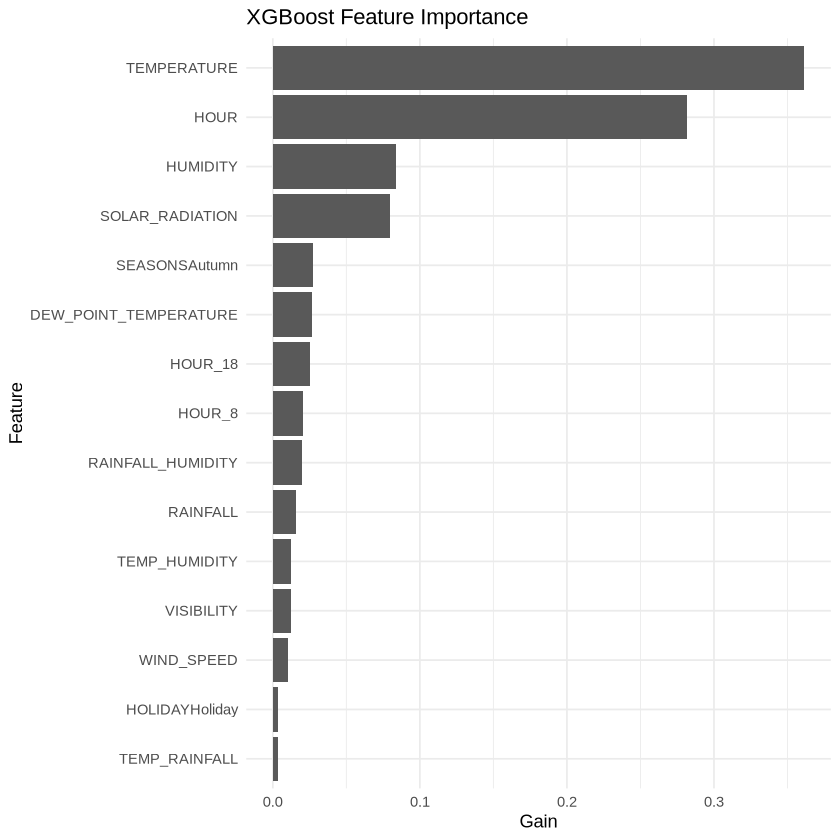

In [8]:
feature_importance %>%
  slice_max(Gain, n = 15) %>%
  ggplot(
    aes(
      x = reorder(Feature, Gain),
      y = Gain
    )
  ) +
  geom_col() +
  coord_flip() +
  labs(
    title = "XGBoost Feature Importance",
    x = "Feature",
    y = "Gain"
  ) +
  theme_minimal()

According to the image above everything with Gain below 0.01 should be removed as these varialbe have so little significance.   
It is possible that they will skew the predictive process of the algorithm in the wrong direction, leadning to inaccurate results.  
This and further feature selection and engineering will be done in a different notebook.